In [3]:
# Install Ultralytics
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.6 MB/s eta 0:00:00


In [1]:
# Cek GPU
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


Install YOLOv8

In [1]:
from ultralytics import YOLO
import os
from IPython.display import display, Image, clear_output
clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 926, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {list(MODES)}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=checks'. Valid modes are ['benchmark', 'export', 'track', 'predict', 'train', 'val'].

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['segment', 'detect', 'pose', 'obb', 'classify']
                MODE (required) is one of ['benchmark', 'export', 'track', 'predict', 'train', 'val']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a 

Train YOLOv8 Model with Custom Dataset

In [1]:
!pip install roboflow

In [2]:
from roboflow import Roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8DxhQ9Ab90iDhstb4YeN")
project = rf.workspace("legolas").project("food-detection-epzr3-pzsaz")
version = project.version(5)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [4]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    name="cafe_model",
    freeze=10
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Food-Detection-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cafe_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fddf9e50740>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Evaluasi

In [5]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1743.2±597.7 MB/s, size: 38.5 KB)
val: Scanning /content/Food-Detection-5/valid/labels.cache... 567 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 567/567 198.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 5.7it/s 6.3s
                   all        567       1116      0.882      0.759       0.82       0.62
            food_drink        378        634      0.856      0.879      0.906      0.767
                person        193        482      0.908      0.639      0.734      0.473
Speed: 1.8ms preprocess, 3.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
b

Confusion Matrix:


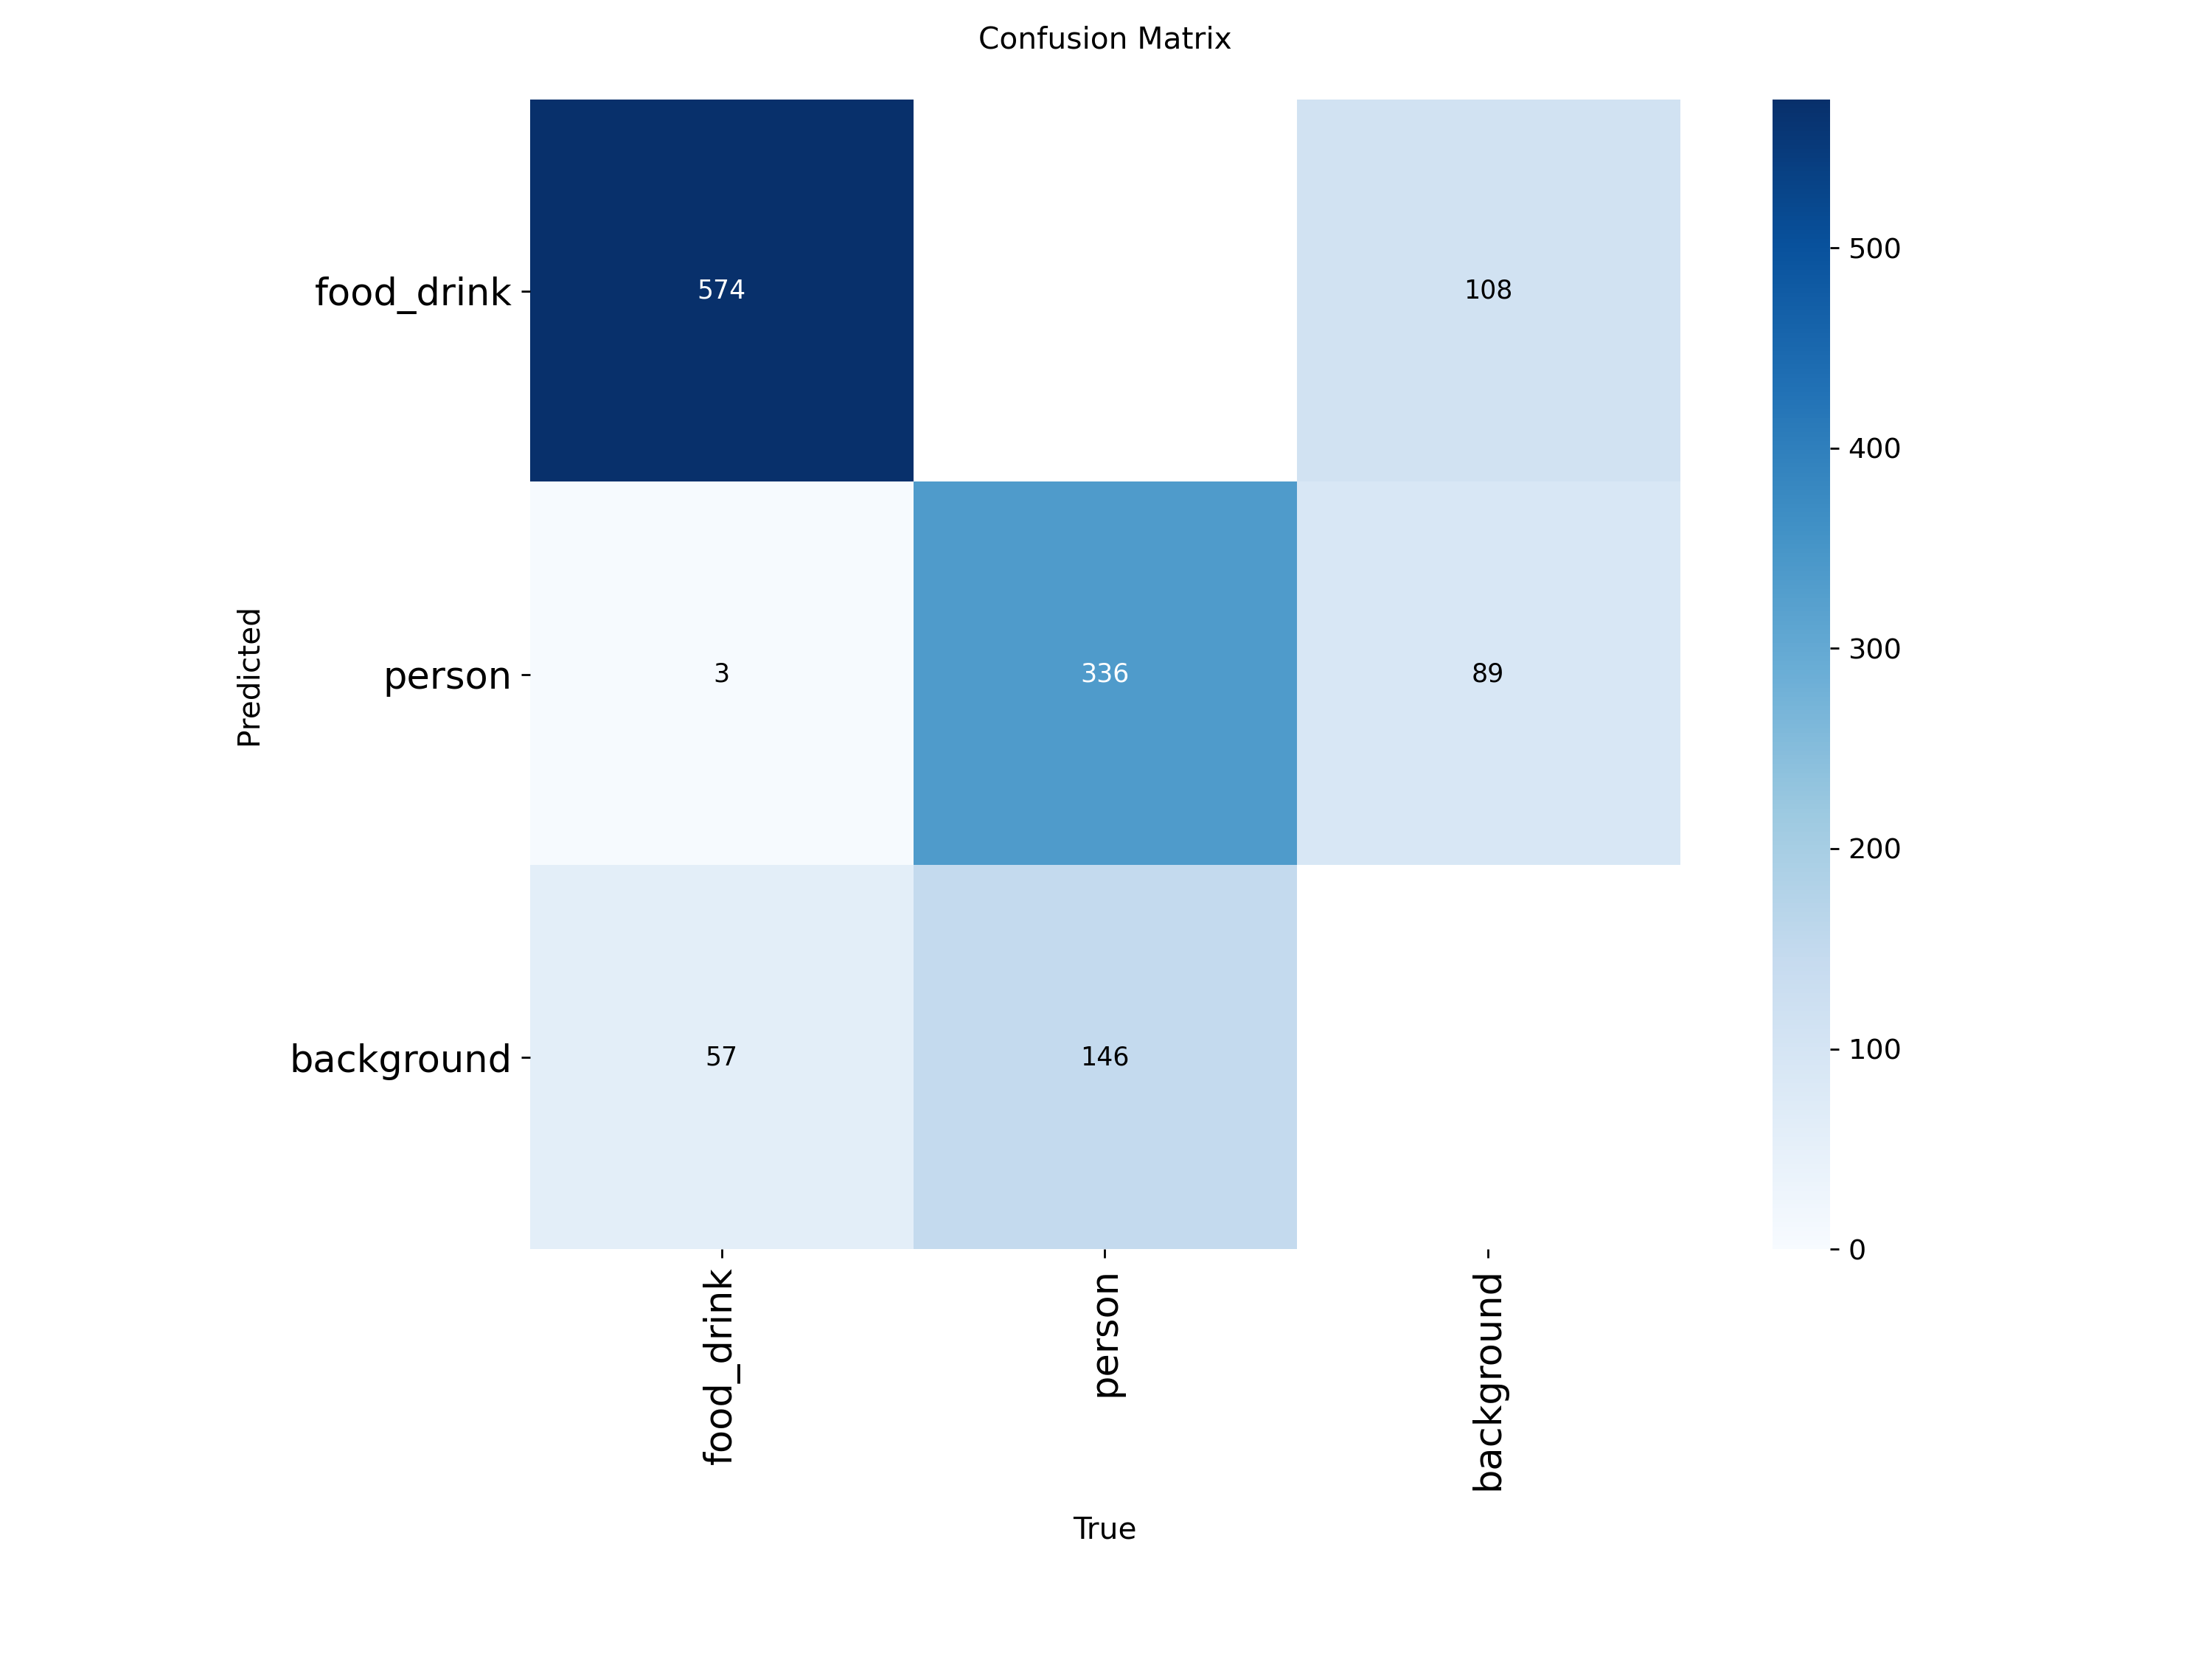

In [6]:
from IPython.display import display, Image
import os

# Assuming 'cafe_model' was the name used during training
run_dir = '/content/runs/detect/cafe_model'

# Display Confusion Matrix
confusion_matrix_path = os.path.join(run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print('Confusion Matrix:')
    display(Image(filename=confusion_matrix_path, width=600))
else:
    print(f'Confusion matrix not found at {confusion_matrix_path}')


Training and Loss Graph:


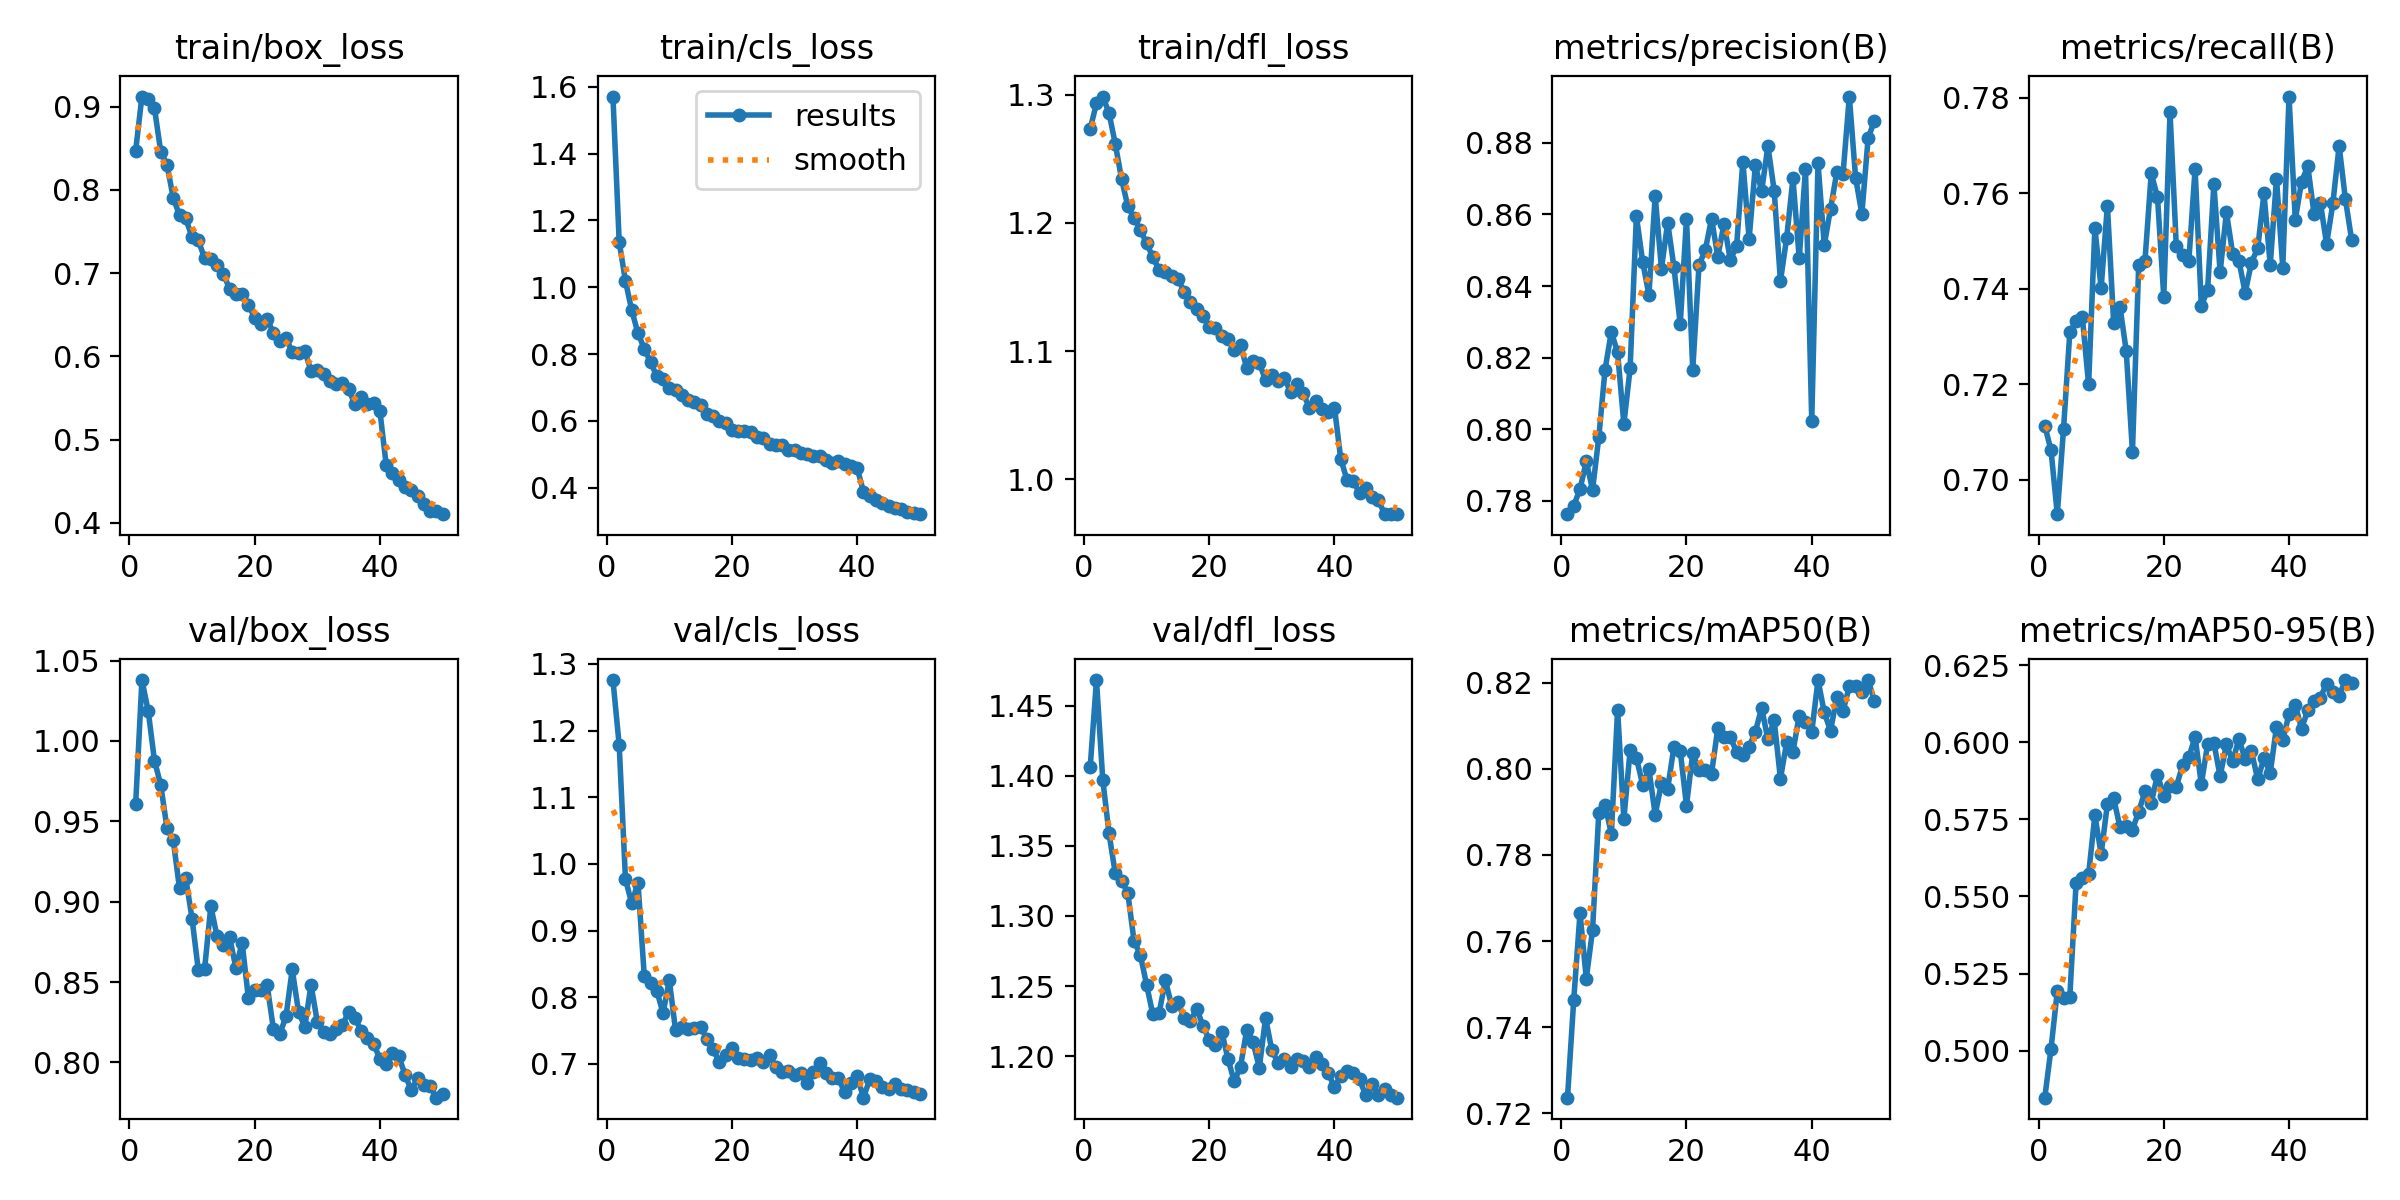

In [7]:
from IPython.display import display, Image
import os

# Assuming 'cafe_model' was the name used during training (needed for run_dir)
run_dir = '/content/runs/detect/cafe_model'

# Display Results (train and loss graphic)
results_plot_path = os.path.join(run_dir, 'results.png')
if os.path.exists(results_plot_path):
    print('\nTraining and Loss Graph:')
    display(Image(filename=results_plot_path, width=800))
else:
    print(f'Training results plot not found at {results_plot_path}')

Testting

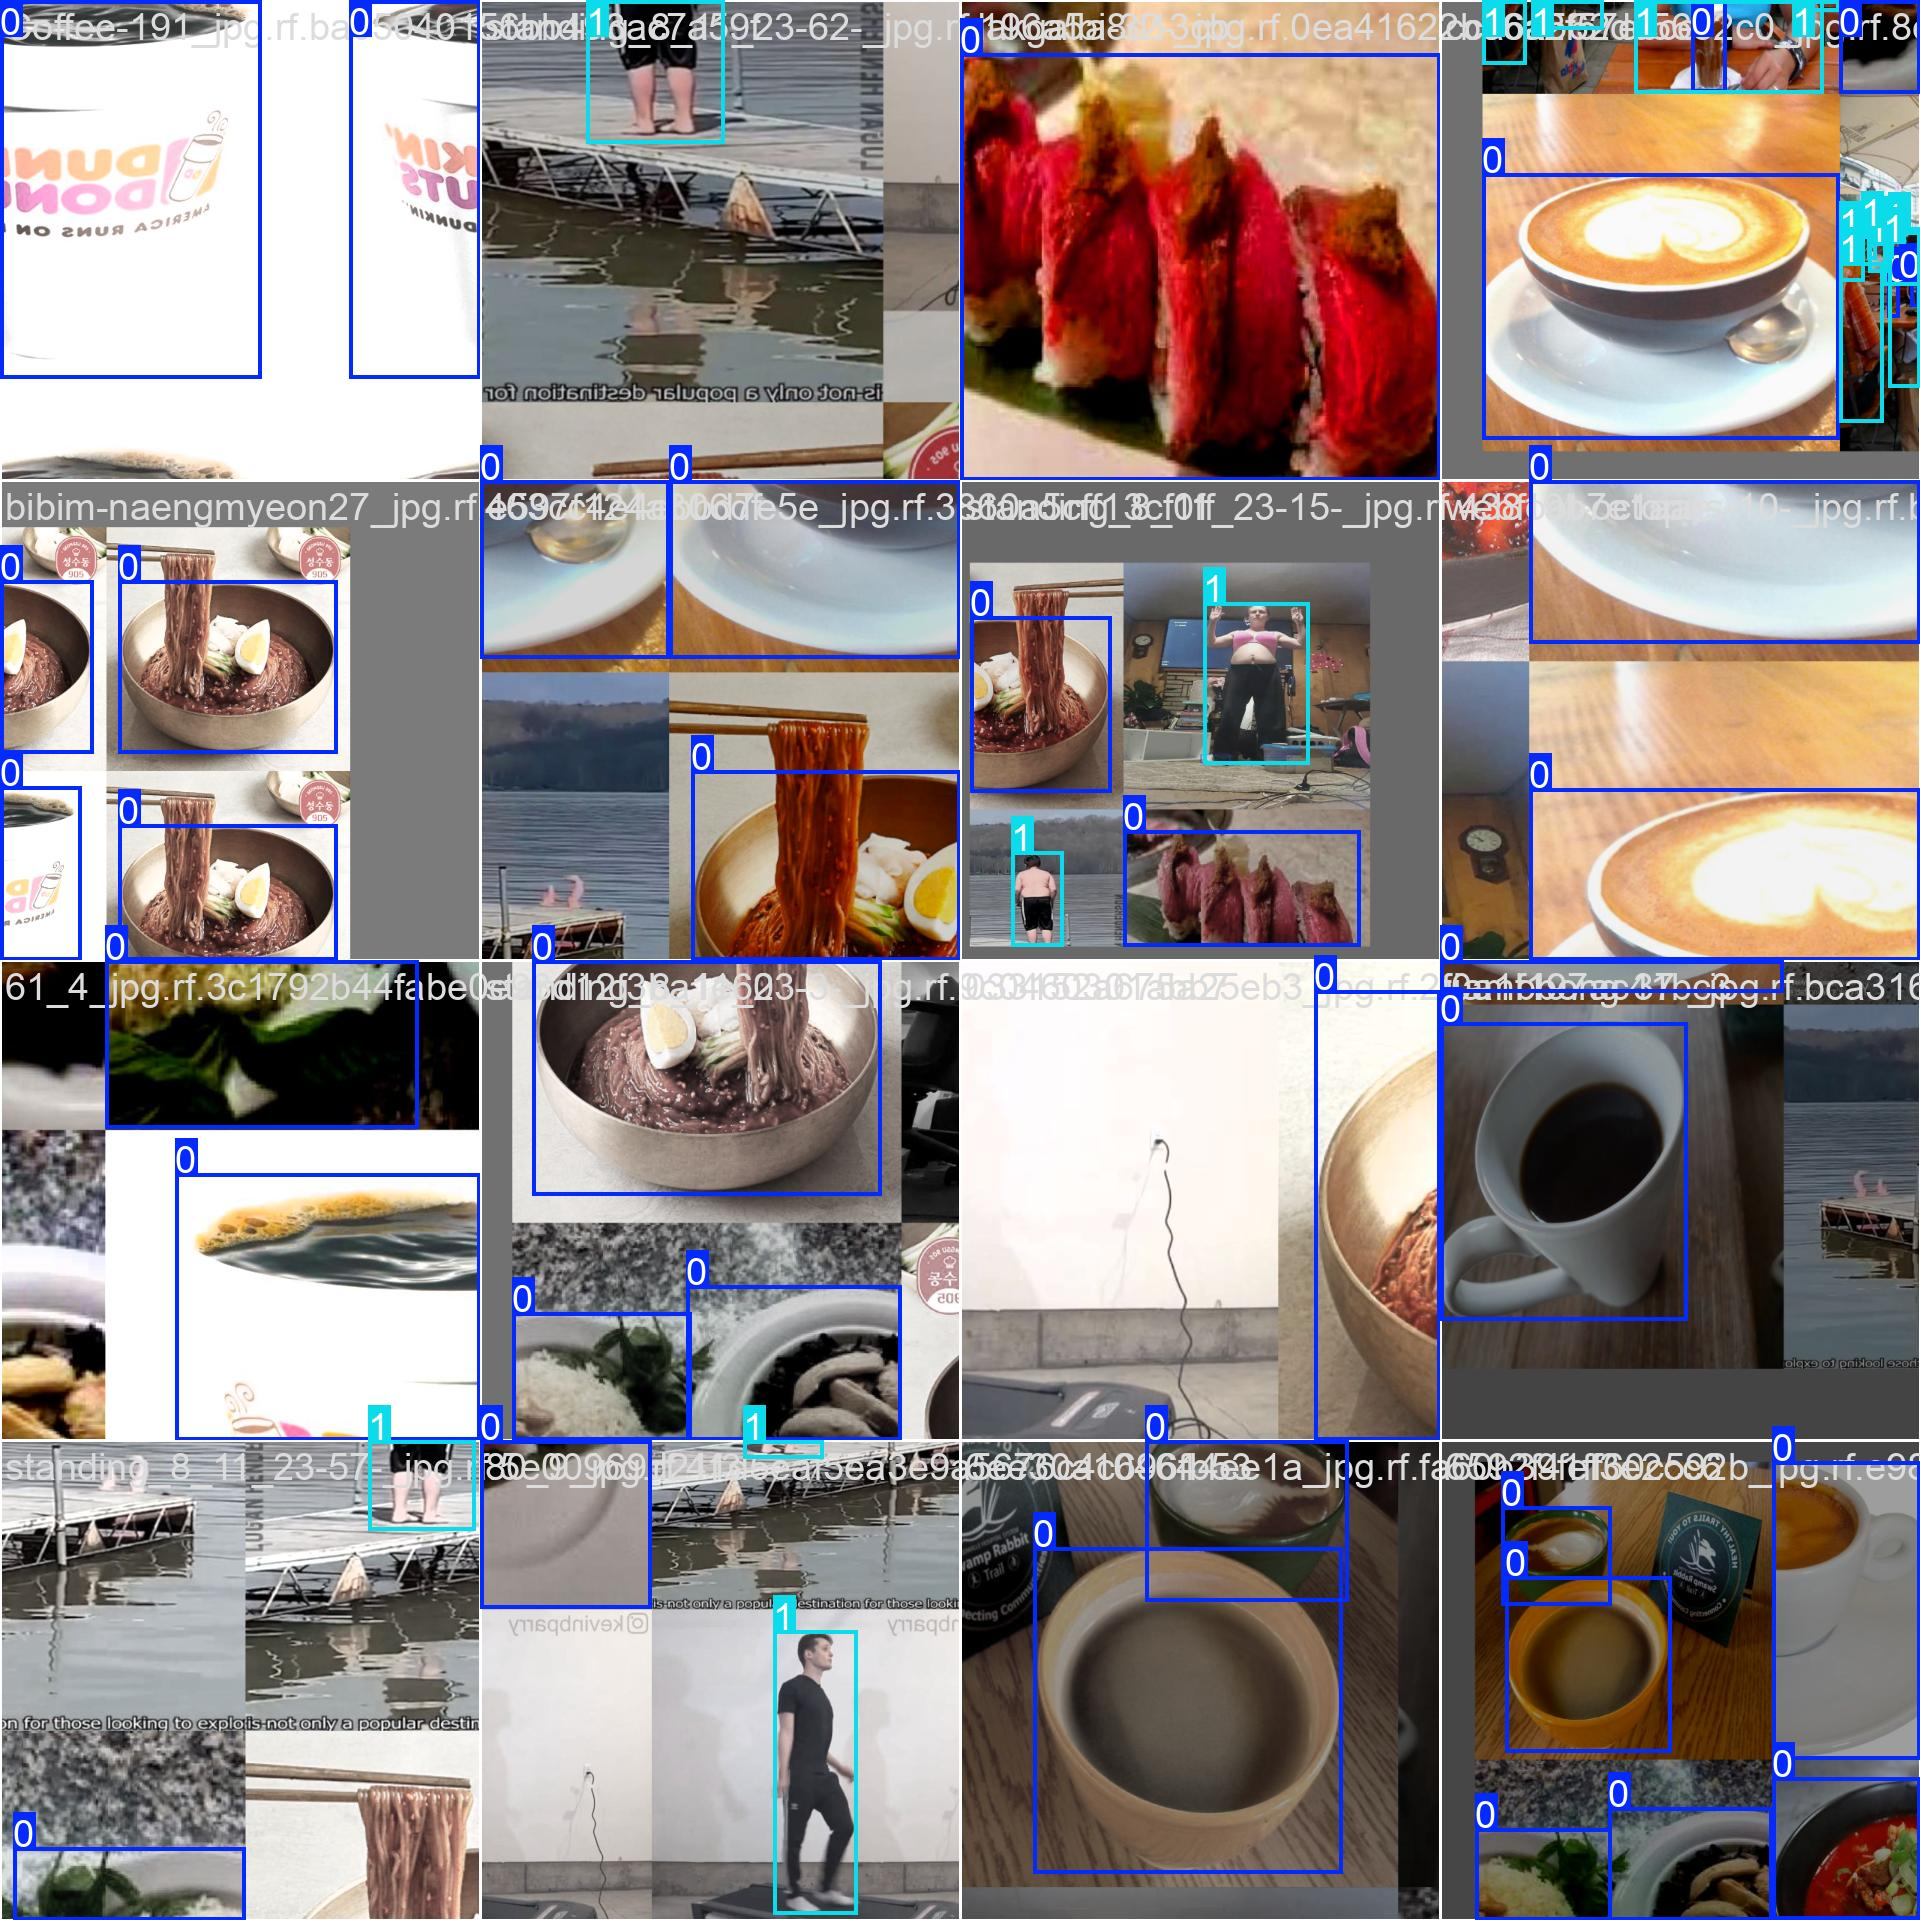

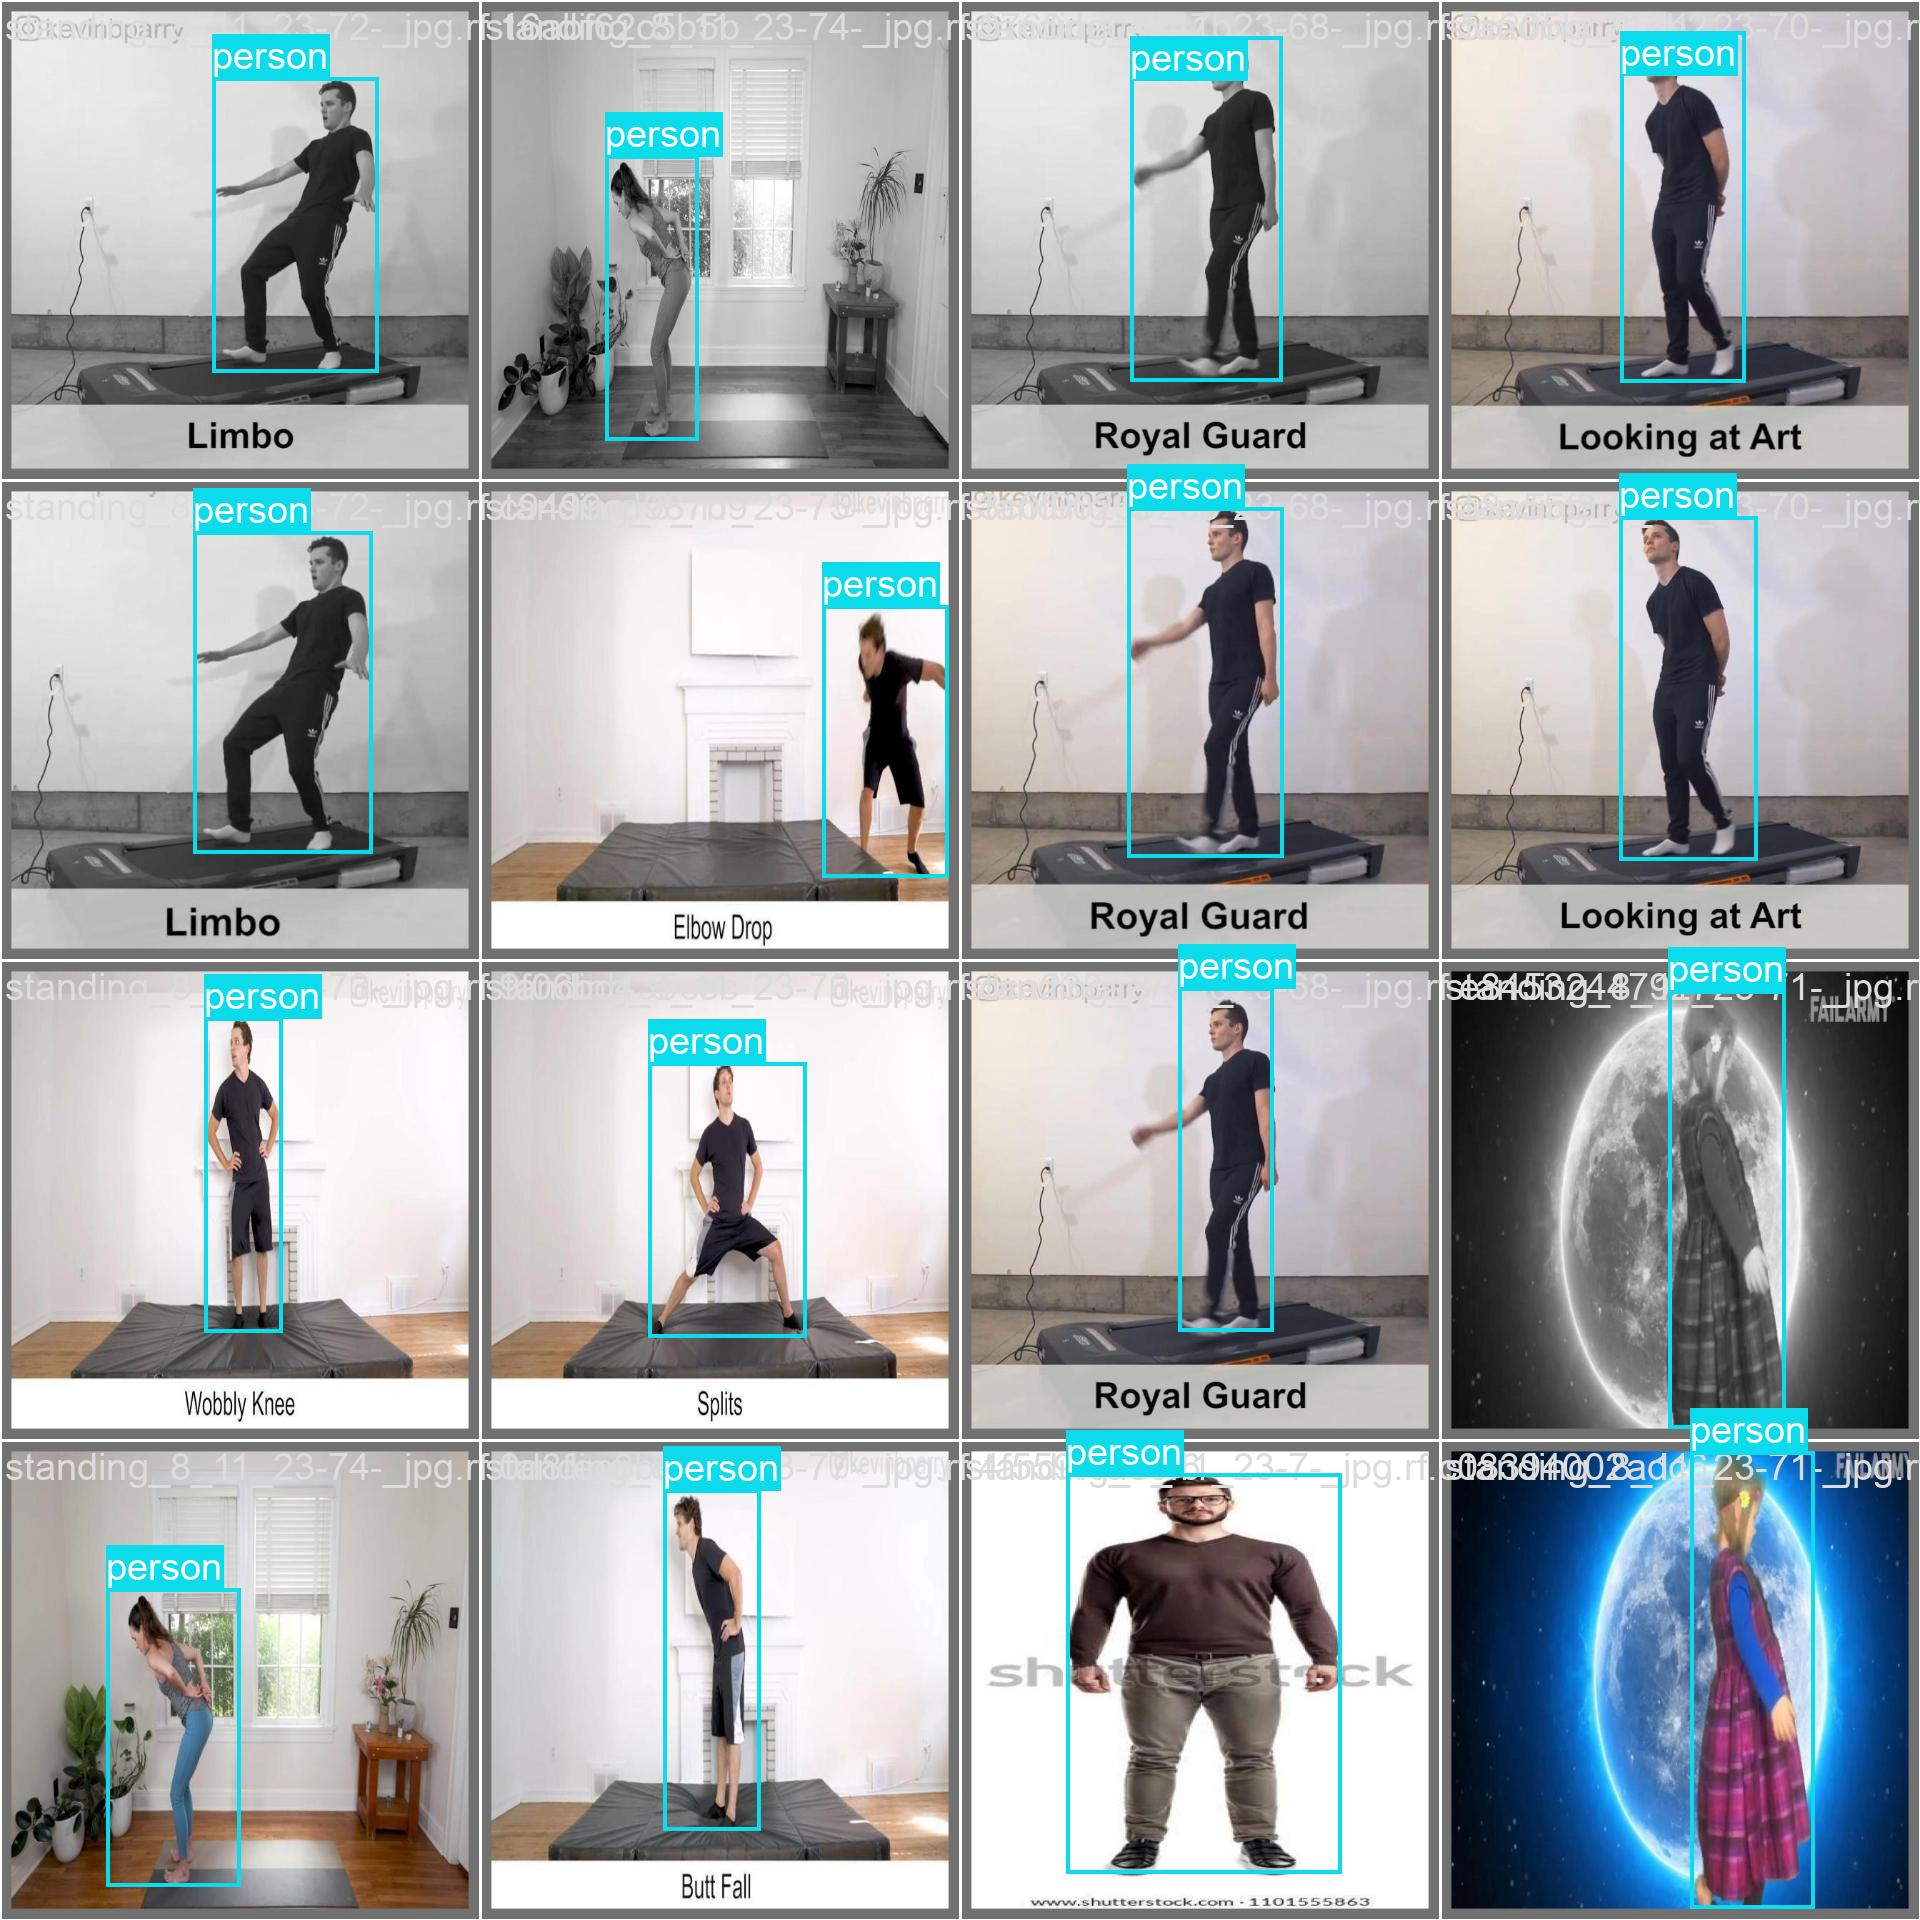

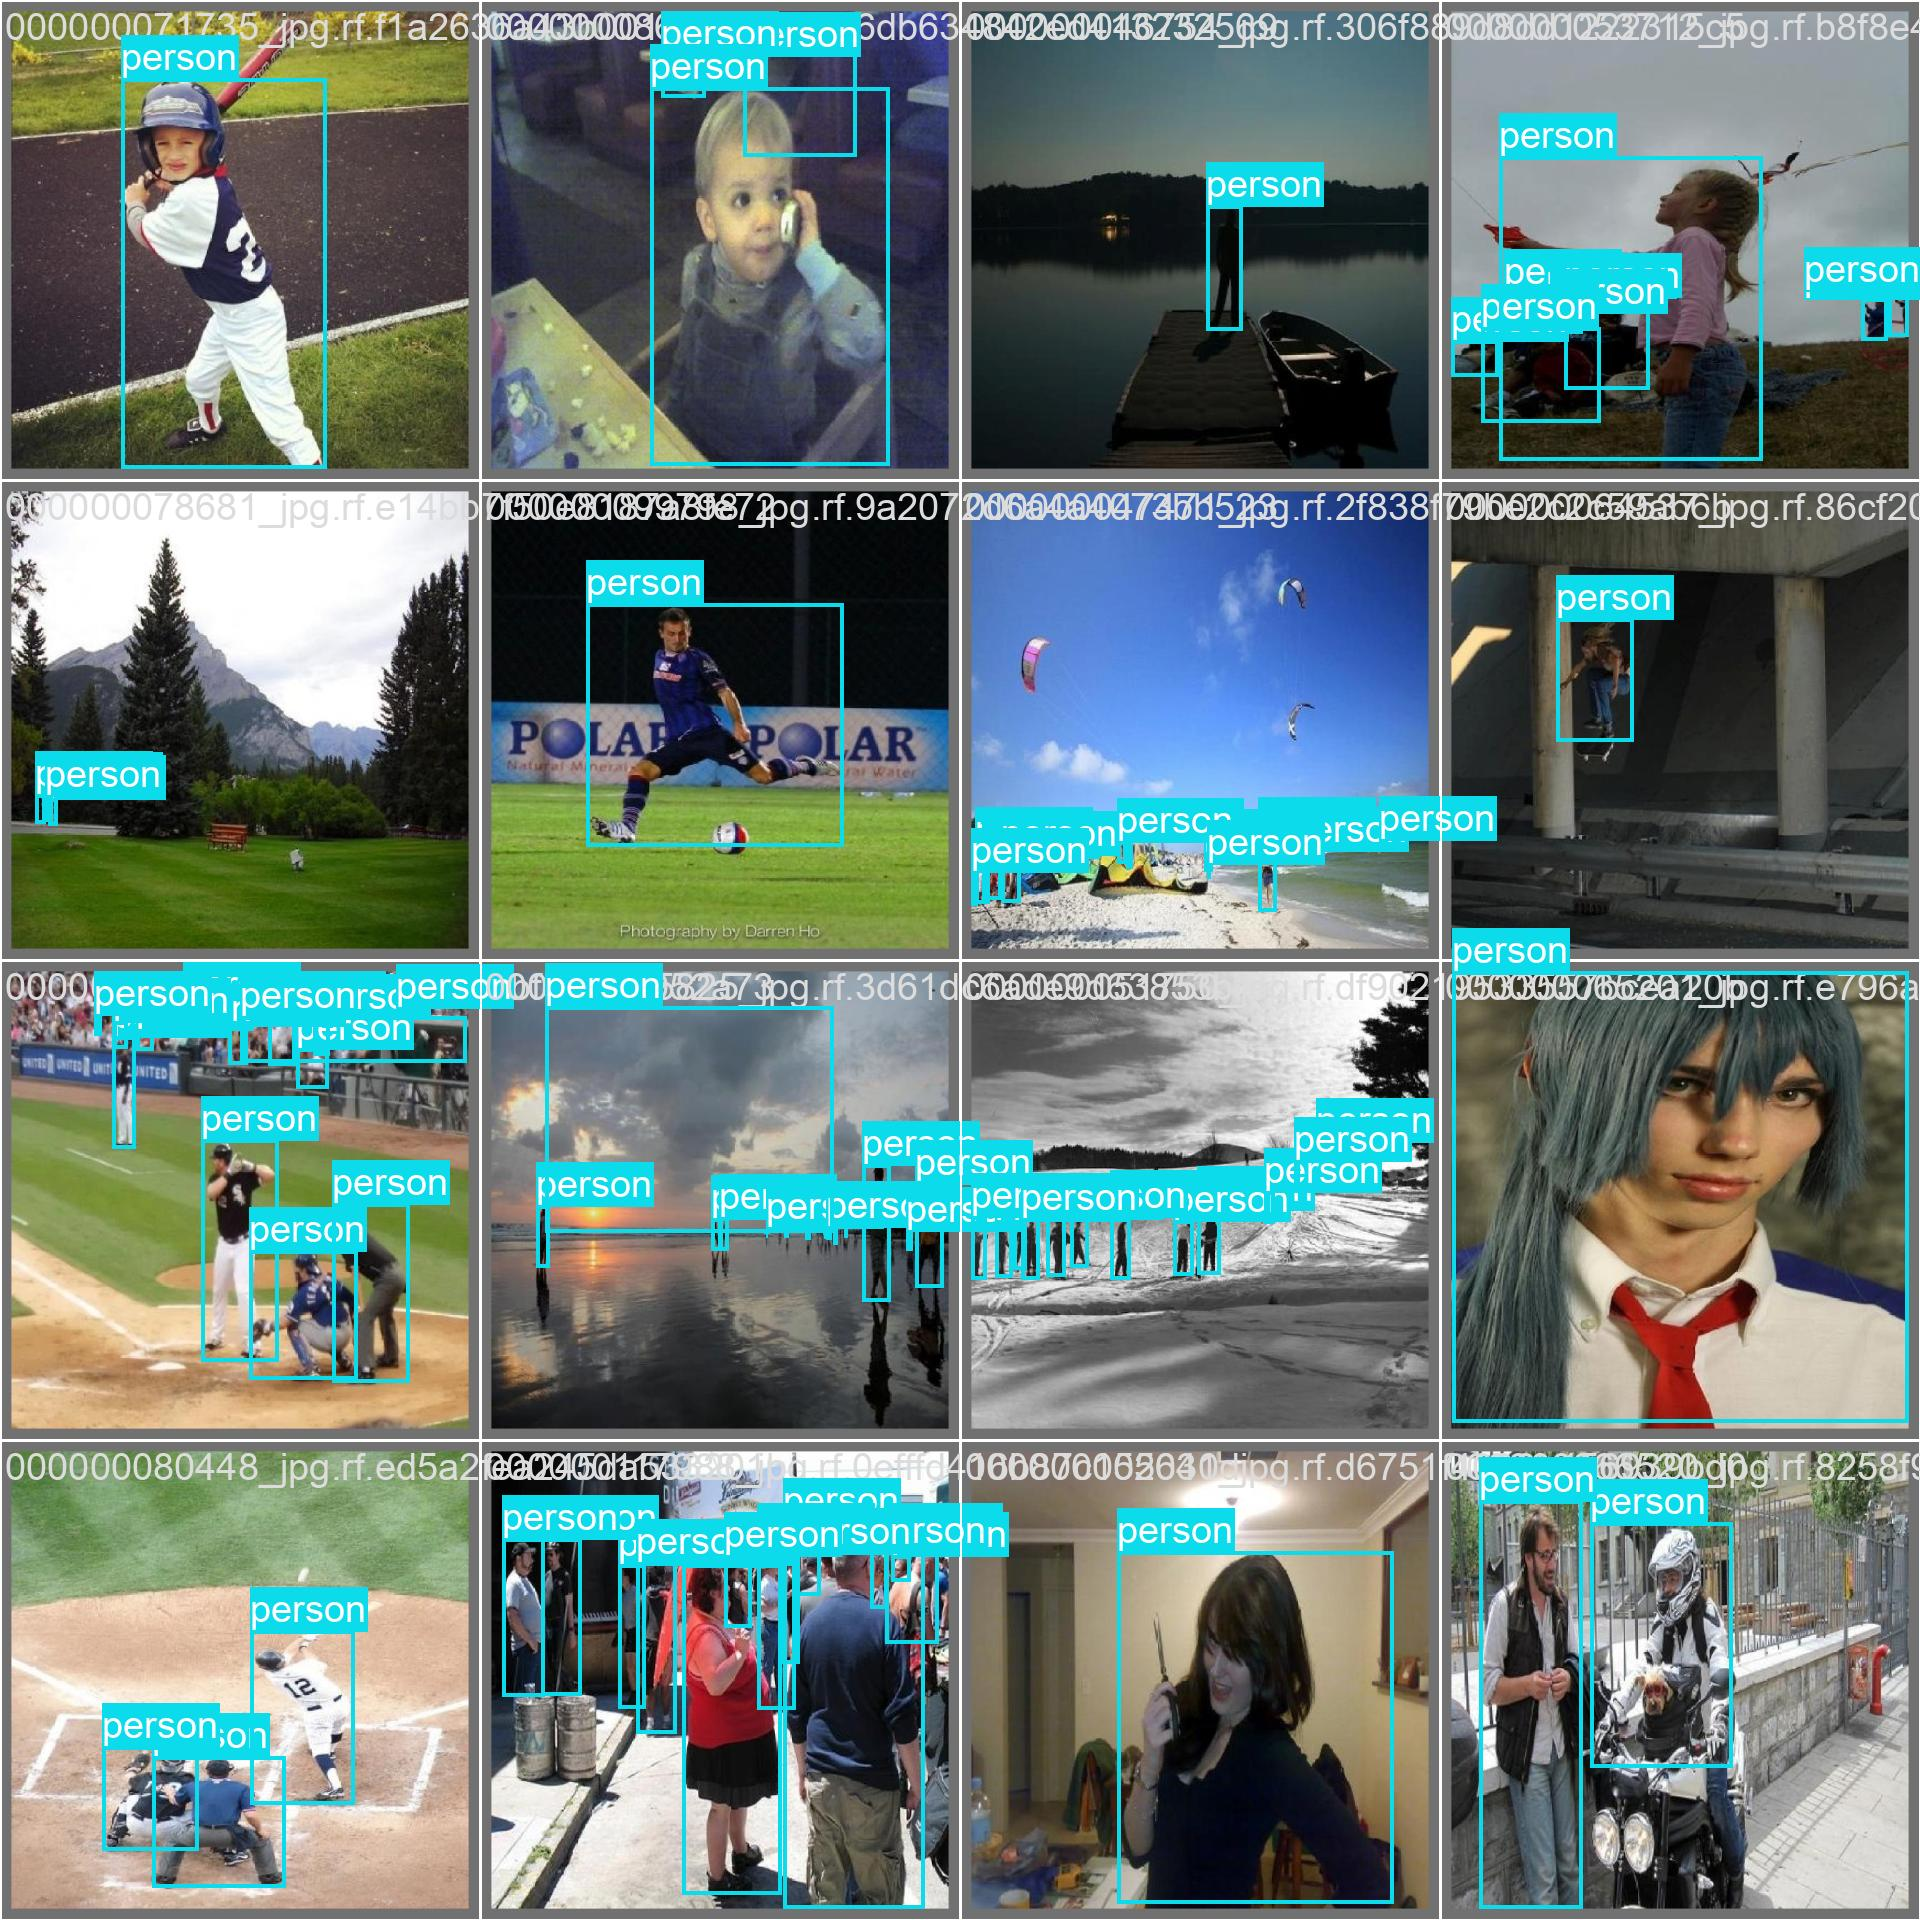

In [8]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{run_dir}/*.jpg')[:3]:
      display(Image(filename=image_path, height=600))
      print("\n")

Save Model

In [13]:
!cp runs/detect/cafe_model/weights/best.pt /content/

In [14]:
print(model.names)

{0: 'food_drink', 1: 'person'}


Export Model ke ONNX

In [15]:
model = YOLO("best.pt")

model.export(
    format="onnx",
    imgsz=416,
    opset=12,
    simplify=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 6, 3549) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 189ms
Prepared 4 packages in 9.68s
Installed 4 packages in 334ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 10.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.90...
ONNX: e

'best.onnx'